<a href="https://colab.research.google.com/github/shivanilokh/rainfall-prediction-ml/blob/main/Car_Price_Predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Dependencies



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

Data Collection and Processing


In [ ]:
# loading the data from csv file to pandas dataframe
car_dataset = pd.read_csv("/content/drive/MyDrive/Car Price Predictions.csv")

In [ ]:
# inspecting the first 5 rows of the dataframe
car_dataset.head()

,Car Name,Year,Selling_Price,present_price,Kms_driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Maruti 800 AC,2007,60000,764853,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,284792,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,964005,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,837005,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,293982,141000,Diesel,Individual,Manual,Second Owner


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# checking the number of rows and columns
car_dataset.shape

(4340, 9)

In [ ]:
# getting some information about the dataset
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car Name       4340 non-null   object
 1   Year           4340 non-null   int64 
 2   Selling_Price  4340 non-null   int64 
 3   present_price  4340 non-null   int64 
 4   Kms_driven     4340 non-null   int64 
 5   Fuel_Type      4340 non-null   object
 6   Seller_Type    4340 non-null   object
 7   Transmission   4340 non-null   object
 8   Owner          4340 non-null   object
dtypes: int64(4), object(5)
memory usage: 305.3+ KB


In [ ]:
# Remove duplicate rows
car_dataset = car_dataset.drop_duplicates()


In [ ]:
# checking the number of missing values
car_dataset.isnull().sum()

,0
Car Name,0
Year,0
Selling_Price,0
present_price,0
Kms_driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
# checking the distribution of categorical data
display(car_dataset.Fuel_Type.value_counts())
display(car_dataset.Seller_Type.value_counts())
display(car_dataset.Transmission.value_counts())

,count
Fuel_Type,
Diesel,2153
Petrol,2123
CNG,40
LPG,23
Electric,1


,count
Seller_Type,
Individual,3244
Dealer,994
Trustmark Dealer,102


,count
Transmission,
Manual,3892
Automatic,448


Plot and Analysis

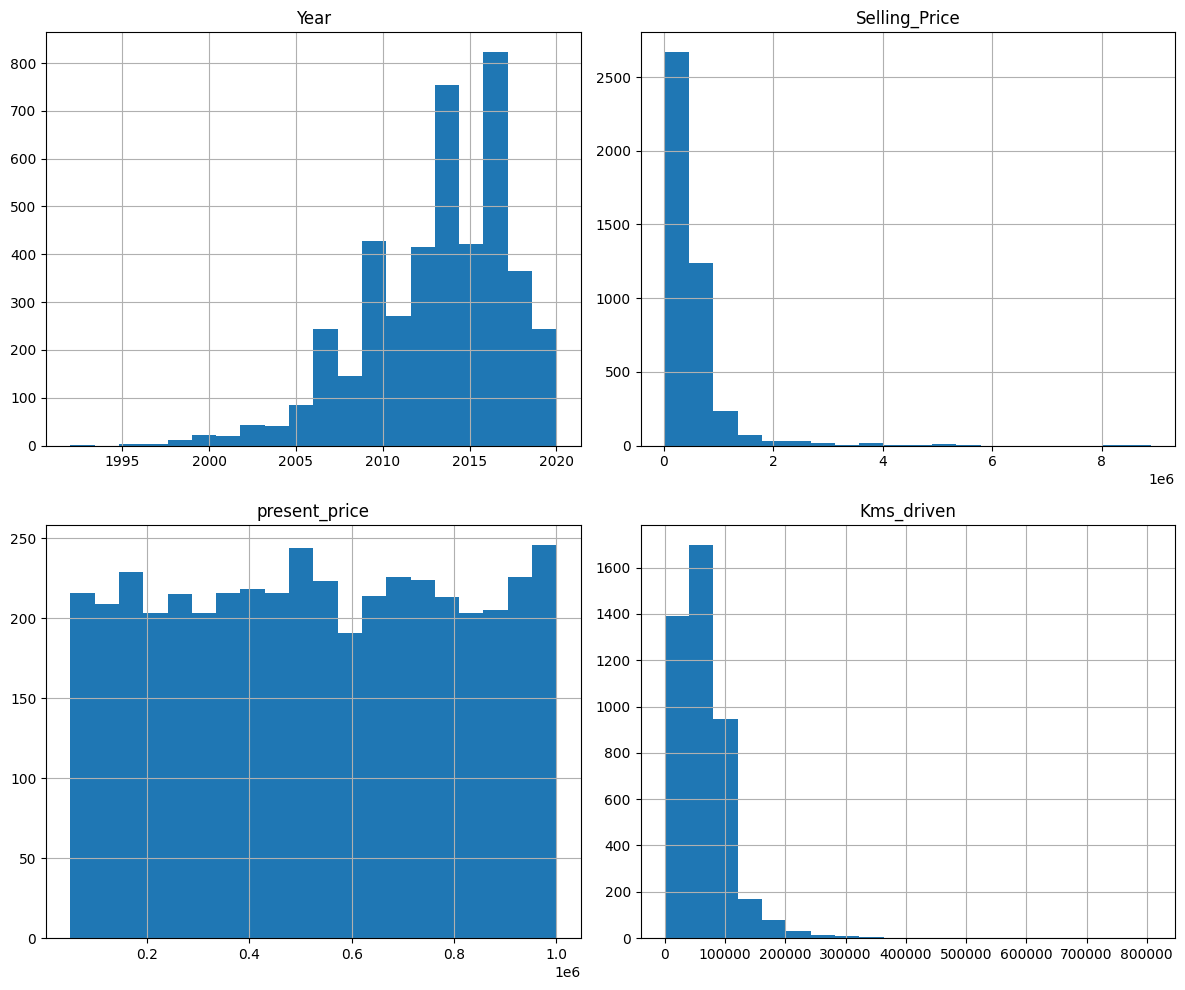

In [ ]:
# Distribution Plots (Histograms)   (#It shows how each column’s values are spread in the dataset)
car_dataset.hist(figsize=(12, 10), bins=20) #means each histogram is divided into 20 value ranges.#figsize=sets the size of the whole plot.
plt.tight_layout()  #Adjusts spacing so the plots don’t overlap.
plt.show()

Feature Engineering - Creating/Selecting/Removing





In [ ]:
display("\n--- SIMPLE FEATURE ENGINEERING & FEATURE SELECTION ---")

# Make a copy of the dataset
data = car_dataset.copy()

# 1️ FEATURE ENGINEERING

# Creating Features (Created new simple features (car_age, km_per_year, price_per_km) to give the model more useful and interpretable information.)
data["car_age"] = 2025 - data["Year"]
data["km_per_year"] = data["Kms_driven"] / (data["car_age"] + 1)
data["price_per_km"] = data["Selling_Price"] / (data["Kms_driven"] + 1)

display("\nNew simple engineered features created:")
display("- car_age: How old the car is")
display("- km_per_year: How much the car was used per year")
display("- price_per_km: Selling price divided by kilometers driven")

# 2️ Removing Features (Removed unnecessary columns like Car_Name and Year to reduce complexity and avoid noise.)

# Remove features that are not useful
data = data.drop(["Car_Name", "Year"], axis=1, errors='ignore')

display("\nRemoved unnecessary features:")
display("- Car_Name (too many categories, low usefulness)")
display("- Year (already used to create car_age)")

# 3️ Selecting Final Features (Selected only the most important features that strongly impact the car price prediction.)

selected_features = [
    "car_age",
    "Kms_driven",
    "km_per_year",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "price_per_km",
    "Selling_Price"
]

final_data = data[selected_features]

display("\nFinal selected features:")
display(selected_features)

# Show final dataset
final_data.head()

'\n--- SIMPLE FEATURE ENGINEERING & FEATURE SELECTION ---'

'\nNew simple engineered features created:'

'- car_age: How old the car is'

'- km_per_year: How much the car was used per year'

'- price_per_km: Selling price divided by kilometers driven'

...

'- Car_Name (too many categories, low usefulness)'

'- Year (already used to create car_age)'

'\nFinal selected features:'

['car_age',
 'Kms_driven',
 'km_per_year',
 'Fuel_Type',
 'Seller_Type',
 'Transmission',
 'Owner',
 'price_per_km',
 'Selling_Price']

,car_age,Kms_driven,km_per_year,Fuel_Type,Seller_Type,Transmission,Owner,price_per_km,Selling_Price
0,18,70000,3684.210526,Petrol,Individual,Manual,First Owner,0.857131,60000
1,18,50000,2631.578947,Petrol,Individual,Manual,First Owner,2.699946,135000
2,13,100000,7142.857143,Diesel,Individual,Manual,First Owner,5.999940,600000
3,8,46000,5111.111111,Petrol,Individual,Manual,First Owner,5.434664,250000
4,11,141000,11750.000000,Diesel,Individual,Manual,Second Owner,3.191467,450000


Encoding the Categorical Data - Encoding converts text categories into numeric values so machine learning models can understand them.

In [ ]:
# encoding "Fuel_Type" Column
car_dataset.replace({'Fuel_Type':{'Petrol':0,'Diesel':1,'CNG':2}},inplace=True)

# encoding "Seller_Type" Column
car_dataset.replace({'Seller_Type':{'Dealer':0,'Individual':1}},inplace=True)

# encoding "Transmission" Column
car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)

/tmp/ipython-input-336345893.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  car_dataset.replace({'Transmission':{'Manual':0,'Automatic':1}},inplace=True)


In [ ]:
car_dataset.head()

,Car Name,Year,Selling_Price,present_price,Kms_driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Maruti 800 AC,2007,60000,764853,70000,0,1,0,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,284792,50000,0,1,0,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,964005,100000,1,1,0,First Owner
3,Datsun RediGO T Option,2017,250000,837005,46000,0,1,0,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,293982,141000,1,1,0,Second Owner


Correlation Heatmap of Car Features - I plotted a heatmap to understand how strongly numerical features are related to each other and to the target.

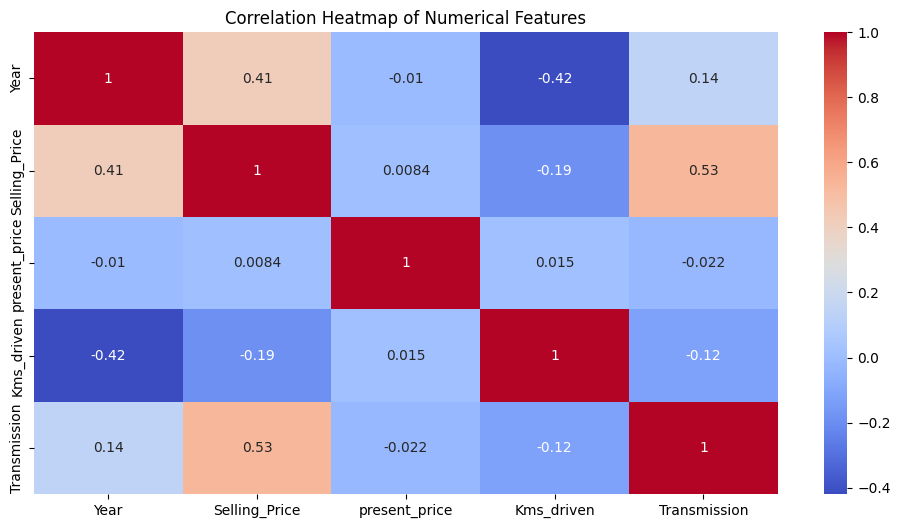

In [ ]:
# Select only numeric columns (Selected only the numerical columns for correlation analysis)
numeric_data = car_dataset.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix (Calculated how strongly each numeric feature is correlated with others.)
corr = numeric_data.corr()

# Plot heatmap (Visualized correlations using a heatmap to identify strong relationships.)
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Data Splitting (X and Y)

In [ ]:
X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"]

display("X shape:", X.shape)
display("y shape:", y.shape)


'X shape:'

(4340, 10)

'y shape:'

(4340,)

In [ ]:
display(X)

,Car Name,present_price,Kms_driven,Fuel_Type,Seller_Type,Transmission,Owner,car_age,km_per_year,price_per_km
0,Maruti 800 AC,764853,70000,Petrol,Individual,Manual,First Owner,18,3684.210526,0.857131
1,Maruti Wagon R LXI Minor,284792,50000,Petrol,Individual,Manual,First Owner,18,2631.578947,2.699946
2,Hyundai Verna 1.6 SX,964005,100000,Diesel,Individual,Manual,First Owner,13,7142.857143,5.999940
3,Datsun RediGO T Option,837005,46000,Petrol,Individual,Manual,First Owner,8,5111.111111,5.434664
4,Honda Amaze VX i-DTEC,293982,141000,Diesel,Individual,Manual,Second Owner,11,11750.000000,3.191467
...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),92096,80000,Diesel,Individual,Manual,Second Owner,11,6666.666667,5.124923
4336,Hyundai i20 Magna 1.4 CRDi,174768,80000,Diesel,Individual,Manual,Second Owner,11,6666.666667,5.124923
4337,Maruti 800 AC BSIII,231617,83000,Petrol,Individual,Manual,Second Owner,16,4882.352941,1.325285
4338,Hyundai Creta 1.6 CRDi SX Option,697198,90000,Diesel,Individual,Manual,First Owner,9,9000.000000,9.611004


In [ ]:
display(y)

,Selling_Price
0,60000
1,135000
2,600000
3,250000
4,450000
...,...
4335,409999
4336,409999
4337,110000
4338,865000


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.1, random_state=2)

In [ ]:
X_train.columns


Index(['Car Name', 'present_price', 'Kms_driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner', 'car_age', 'km_per_year', 'price_per_km'],
      dtype='object')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

display("Train/Test Split completed!")


'Train/Test Split completed!'

Data Standardization-Standardization scales all numerical features so they have similar ranges, which helps the model learn better

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Scale only the numeric features (created a scaler object to standardize numeric values)
scaler = StandardScaler() #created a scaler object to standardize numeric values
X_scaled = scaler.fit_transform(X_numeric) #applied standardization so all numeric features have mean 0 and standard deviation 1

display("Standardization done on numeric columns only!")  #This confirms that scaling is completed


'Standardization done on numeric columns only!'

Balancing the Dataset with SMOTE Oversampling (SMOTE creates synthetic samples for the minority class to make the dataset balanced)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

# Use only numeric columns
X_numeric = X.select_dtypes(include=['int64', 'float64'])

# Create oversampler (We use RandomOverSampler to balance the dataset by duplicating minority class samples)
ros = RandomOverSampler(random_state=42)

# Apply oversampling (Oversampling increases the number of minority samples so the model trains on balanced data.)
X_resampled, y_resampled = ros.fit_resample(X_numeric, y)

display("Oversampling completed!")
display("Before:", y.value_counts())
display("After:", y_resampled.value_counts())


'Oversampling completed!'

'Before:'

,count
Selling_Price,
300000,162
250000,125
350000,122
550000,107
600000,103
...,...
749000,1
233000,1
614000,1


'After:'

,count
Selling_Price,
865000,162
60000,162
135000,162
600000,162
250000,162
...,...
975000,162
1425000,162
1964999,162


# Model Training

     Linear Regression





In [ ]:
# loading the linear regression model (initialized the Linear Regression model to start training)
lin_reg_model = LinearRegression()

In [ ]:
#Check the total input features (X) and target output (Y) dimensions.
display("X shape:", X.shape)
display("Y shape:", y.shape)


'X shape:'

(4340, 10)

'Y shape:'

(4340,)

In [ ]:
#This confirms the train–test split sizes are correct
display("X_train shape:", X_train.shape)
display("Y_train shape:", Y_train.shape)
display("X_test shape:", X_test.shape)
display("Y_test shape:", Y_test.shape)


'X_train shape:'

(3472, 10)

'Y_train shape:'

(3906,)

'X_test shape:'

(868, 10)

'Y_test shape:'

(434,)

In [ ]:
X.dtypes


,0
Car Name,object
present_price,int64
Kms_driven,int64
Fuel_Type,object
Seller_Type,object
Transmission,object
Owner,object
car_age,int64
km_per_year,float64
price_per_km,float64


In [ ]:
# This block prepares the data by cleaning, encoding, and splitting it into training and testing sets
df = car_dataset.copy()

df = df.dropna()

Y = df['Selling_Price']
X = df.drop(columns=['Selling_Price'])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

display(X_train.shape, Y_train.shape)


(3472, 1504)

(3472,)

In [ ]:
#The model learns the relationship between features and the selling price
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train, Y_train)


LinearRegression()

In [ ]:
#I trained the model and generated predictions on the test set
model = LinearRegression()
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

display("Model trained successfully!")


'Model trained successfully!'

Hyperparameter Tuning of Random Forest using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Create the model
rf = RandomForestRegressor()

# 2. Create the parameter grid (simple and small)
param_grid = {              # Define a grid of hyperparameters to search.
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 3. GridSearchCV
grid_search = GridSearchCV(    #Set up GridSearchCV with model, parameters, CV, scoring, and parallel jobs.
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# 4. Fit the model
grid_search.fit(X_train, Y_train)   #Train models on all parameter combinations using training data.

# 5. Best parameters
display("Best Parameters:", grid_search.best_params_)
display("Best Score (CV R²):", grid_search.best_score_)  #Show the highest cross-validated R² score.

# 6. Best model
best_rf = grid_search.best_estimator_  #Get the model with the best parameters.

# 7. Test set prediction
y_pred = best_rf.predict(X_test)  #Predict target values on the test set using the best model.


Fitting 3 folds for each of 18 candidates, totalling 54 fits


'Best Parameters:'

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}

'Best Score (CV R²):'

np.float64(0.7108715212083244)

Evaluating Linear Regression Performance




In [ ]:
# prediction on training data
training_pred = model.predict(X_train)  #Predict values on the training dataset using the model

# R squared (Calculate R² score for training predictions.)
r2_train = metrics.r2_score(Y_train, training_pred)

display("R-squared on Training Data:", r2_train) #Display the R² score for training predictions.


'R-squared on Training Data:'

0.981929904073606

Model Evaluation

In [ ]:
# prediction on Training data
training_data_prediction = lin_reg_model.predict(X_train)

In [ ]:
# prediction on Training data
training_data_prediction = model.predict(X_train)

# R squared Error
from sklearn import metrics
error_score = metrics.r2_score(Y_train, training_data_prediction)

display("R squared Error :", error_score)


'R squared Error :'

0.981929904073606

Visualize the actual prices and Predicted prices


In [ ]:
import pandas as pd

# Assuming X_train and X_test are your original dataframes
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_encoded, Y_train)

LinearRegression()

In [ ]:
Y_pred = model.predict(X_test_encoded)

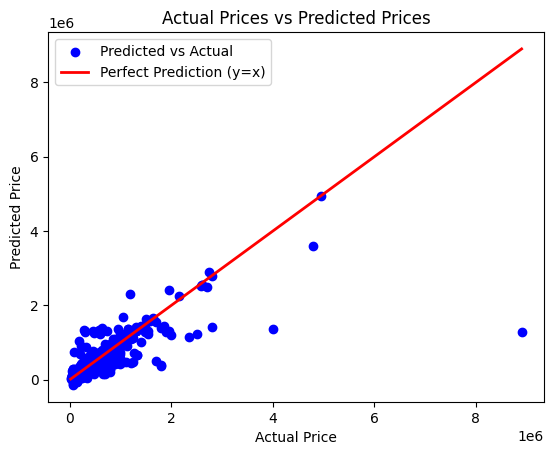

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(Y_test, Y_pred, color='blue', label='Predicted vs Actual')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], color='red', linewidth=2, label='Perfect Prediction (y=x)') #Plot a reference line for perfect predictions.
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Prices vs Predicted Prices')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score
error_score = r2_score(Y_test, Y_pred)  #Calculate R² score score on test data.
display("R squared Error : ", error_score)

'R squared Error : '

0.6015217794566041

In [ ]:
import pickle


In [ ]:
with open("car_price_model.pkl", "wb") as file:
    pickle.dump(model, file)


In [ ]:
!ls


car_price_model.pkl  drive  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p /content/drive/MyDrive/Car_Project


In [ ]:
!cp car_price_model.pkl /content/drive/MyDrive/Car_Project/


In [ ]:
!ls /content/drive/MyDrive/Car_Project


car_price_model.pkl
